# **Project : Product Return Prediction**


## Introduction
In this project, we focus on understanding the reasons behind product returns and predict whether a product will be returned. Our primary goal is to provide actionable insights to retailers rather than achieving the maximum model accuracy. By identifying patterns and factors that leads to returns, we aim to help businesses to reduce return rates and associated costs.


## Problem Statement
To Predict the likelihood of a product being returned based on various features such as product category, price and customer demographics. The goal of this project is to provide insights into the factors that contribute to product returns, enabling reatilers to make informed decisions and improve their return policies and customer experience.


## Business Problem
In the retail industry, product returns are a significant challenge, impacting profitablity and customer satisfaction. Understanding the reasons behind returns can help retailers improve their products, services and customer experience.     


## Mapping the Real-World Problem to a Machine Learning Problem
**It is a machine learning binary classification problem where we predict whether a order will be returned or not. By analyzing various order features, its aim to help businesses reduce return rates and improve customer satisfaction.**


### Import Libraries


In [183]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable
import datetime as dt


### Dispaly Settings


In [133]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')


In [134]:
### Data Ingestion and Exploration
path = Path.cwd()
paths = path.parent.joinpath('data', 'raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)


['.gitkeep', 'Global Superstore.xls']


In [135]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1),
    return_df.tail(1),
    people_df.tail(1))


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [136]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)


'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [137]:
# remove whitespaces from column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip()


In [138]:
# Lets lower case all column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.lower()


In [139]:
# lets check the data types of the columns
order_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row id          51290 non-null  int64         
 1   order id        51290 non-null  object        
 2   order date      51290 non-null  datetime64[ns]
 3   ship date       51290 non-null  datetime64[ns]
 4   ship mode       51290 non-null  object        
 5   customer id     51290 non-null  object        
 6   customer name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product id      51290 non-null  object        
 15  ca

In [140]:
return_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [141]:
people_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   person  13 non-null     object
 1   region  13 non-null     object
dtypes: object(2)
memory usage: 340.0+ bytes


**Dataset Summary**

**The Global Superstore dataset contains three sheets: Orders, Returns and People.**
    
- **The Orders sheet contains information about customer orders, including order ID, customer ID, demographic details ,product details and sales data.**    
- **The Returns sheet contains information about returned orders, including order ID and market details.**    
- **The people sheet contains information about customers, including customer name and demographic details.**
    
**The data spans a robust four-year period from 2011 to 2015 . This dataset contains a vast array of order-related information, offering insights into retail operations across 147 countries.**



Brief description of columns:

- **Order Information**

    - **Order ID** – Unique identifier for each order.

    - **Order Date** – Date when the order was placed.

    - **Ship Date** – Date when the order was shipped.

    - **Ship Mode** – Shipping method (e.g., Standard Class, Second Class, First Class, Same Day).

- **Customer Information**

    - **Customer ID** – Unique identifier for each customer.

    - **Customer Name** – Name of the customer.

    - **Segment** – Customer segment (Consumer, Corporate, Home Office).

    - **Country** – Country where the customer is located.

    - **City / State / Region** – Geographic details of the customer.

- **Product Information**

    - **Product ID** – Unique identifier for each product.

    - **Category** – Broad product category (Furniture, Office Supplies, Technology).

    - **Sub-Category** – More specific product type (e.g., Chairs, Phones, Binders).

    - **Product Name** – Name/description of the product.

- **Sales & Profit Metrics**

    - **Sales** – Revenue generated from the order.

    - **Quantity** – Number of units sold.

    - **Discount** – Discount applied to the order.

    - **Profit** – Profit earned from the order after costs.

- **Geographic & Managerial**

    - **Region** – Region of the world (e.g., Asia, Europe, US).

    - **Postal Code** – Postal/ZIP code of the customer.

    - **Market** – Market grouping (e.g., APAC, EMEA).

- **Returns (separate sheet)**

    - **Returned** – Indicates whether an order was returned.


In [142]:
order_df.columns = order_df.columns.str.replace(' ', '_')
return_df.columns = return_df.columns.str.replace(' ', '_')

## **Number Formatting and Category Consistency**

In [143]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
dtype_df

,dtype,nunique,unique
row_id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order_id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order_date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship_date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship_mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer_id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer_name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


In [144]:
def highlight_zero_neg(val):
    if val == 0:
        return 'background-color: yellow; color: black'   # zero values highlighted in yellow
    elif val < 0:
        return 'background-color: red; color: white'    # negative values highlighted in red
    else:
        return ''  # no highlight for positive values


In [145]:
# Number Formatting and data description for numerical columns
df_desc = order_df.describe(exclude='object')
display(df_desc.style.applymap(highlight_zero_neg, subset = df_desc.select_dtypes(include='number').columns))


,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.500000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.291990,nan,nan,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


**NOTEs**:
- **Discount**: The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.
- **Profit**: The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


In [146]:
order_df.describe(include='object')

,order_id,ship_mode,customer_id,customer_name,segment,city,state,country,market,region,product_id,category,sub-category,product_name,order_priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


### **Missing Value Analysis**

In [147]:
missing_df = order_df.stb.missing()
missing_df[missing_df['missing']!=0]


,missing,total,percent
postal_code,41296,51290,80.51472


In [148]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order_id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**


- **Lets explore return dataframe and transform return_df column to bool type and examine if market category is clean(no two or more names for same market, etc.)**

In [149]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df


In [150]:
# let's clean return_df and store as returns
returns = clean_return_df(return_df)
returns.head()

,returned,order_id,market
0,True,MX-2013-168137,LATAM
1,True,US-2011-165316,LATAM
2,True,ES-2013-1525878,EU
3,True,CA-2013-118311,US
4,True,ES-2011-1276768,EU


### **Extract new columns from existing columns of given dataframes.**

In [151]:
# Requirement gathering of data for seasonal analysis
print(f"Order Date Data Type: {order_df['order_date'].dtype}")
print(order_df['order_date'].head(1))

Order Date Data Type: datetime64[ns]
0   2012-07-31
Name: order_date, dtype: datetime64[ns]


In [152]:
# Create new dimensions from order date column like year, month, week, dayofyear, etc.
order_df['order_year'] = order_df['order_date'].dt.year
order_df['order_month'] = order_df['order_date'].dt.month
order_df['order_week'] = order_df['order_date'].dt.isocalendar().week
order_df['order_dayofyear'] = order_df['order_date'].dt.dayofyear   
print("Newly created date dimensions:", '\n', order_df[['order_date','order_year', 'order_month', 'order_week', 'order_dayofyear']].head(4))

Newly created date dimensions: 
   order_date  order_year  order_month  order_week  order_dayofyear
0 2012-07-31        2012            7          31              213
1 2013-02-05        2013            2           6               36
2 2013-10-17        2013           10          42              290
3 2013-01-28        2013            1           5               28


# **Exploratory Data Analysis**

### **Customers Analysis**

1. Profile the customers based on their frequency of purchase - calculate frequency of purchase for each customer.
2. Do the high frequent customers are contributing more revenue.
3. Are they also profitable - what is the profit margin across the buckets.
4. Which customer segment is most profitable in each year.
5. How the customers are distributed across the countries.


#### **1. Profile the customers based on their frequency of purchase - calculate frequency of purchase for each customer.**

In [153]:
# First compute unique number of customers each year.
# Second compute frequency of purchase for each customer by counting number of orders placed by each customer. 
# compute unique number of customers each year
unique_customer = order_df.groupby(['order_year'])['customer_name'].nunique()
order_df['unique_customer_within_year'] = order_df['order_year'].map(lambda x: unique_customer[x])

order_df.head(1)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,order_year,order_month,order_week,order_dayofyear,unique_customer_within_year
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.65,7,0.0,762.1845,933.57,Critical,2012,7,31,213,795


In [154]:
purchase_freq = order_df.groupby(['order_year','customer_name']).agg(
    frequency = ('customer_name', 'count'),
    total_customer_each_year = ('unique_customer_within_year', 'max'),
    revenue = ('sales', 'sum'),
    profit = ('profit', 'sum')
)

purchase_freq.head()

frequency  total_customer_each_year     revenue  \
order_year customer_name                                                      
2011       Aaron Bergman           14                       795   958.10200   
           Aaron Hawkins           15                       795  8830.70950   
           Aaron Smayling           8                       795  1995.09800   
           Adam Bellavance          6                       795  1369.20270   
           Adam Hart               19                       795  4513.61792   

                                profit  
order_year customer_name                
2011       Aaron Bergman     189.26450  
           Aaron Hawkins    1528.25570  
           Aaron Smayling    180.54020  
           Adam Bellavance   370.65270  
           Adam Hart         322.34912

**Frequency of Purchase for Each Customer** is computed by dividing the total number of orders by the unique number of customers within a specified time frame.
This is crucial metric for business to understand **customer retention and buying behaviour**.

In [155]:
## compute frequency of purchase of each customer = df['frequency']/df['total_customer_each_year]
purchase_freq['customer_frequency_purchase'] = (purchase_freq['frequency'] / purchase_freq['total_customer_each_year'])*100
purchase_freq.head().round(4)

frequency  total_customer_each_year    revenue  \
order_year customer_name                                                     
2011       Aaron Bergman           14                       795   958.1020   
           Aaron Hawkins           15                       795  8830.7095   
           Aaron Smayling           8                       795  1995.0980   
           Adam Bellavance          6                       795  1369.2027   
           Adam Hart               19                       795  4513.6179   

                               profit  customer_frequency_purchase  
order_year customer_name                                            
2011       Aaron Bergman     189.2645                       1.7610  
           Aaron Hawkins    1528.2557                       1.8868  
           Aaron Smayling    180.5402                       1.0063  
           Adam Bellavance   370.6527                       0.7547  
           Adam Hart         322.3491                       2.3899

**purchase_freq** dataframe profile customer about their frequency of purchase.

### **Do the high frequent customers are contributing more revenue.**


Need to answer whether high frequency customer of each year generate more revenue or not. Will compute highest purchase frequncy customer of each year and compare it with highest revenue generator of that year.

In [156]:
## revenue is same as sales and add column in freq_purchase
purchase_freq.head()

frequency  total_customer_each_year     revenue  \
order_year customer_name                                                      
2011       Aaron Bergman           14                       795   958.10200   
           Aaron Hawkins           15                       795  8830.70950   
           Aaron Smayling           8                       795  1995.09800   
           Adam Bellavance          6                       795  1369.20270   
           Adam Hart               19                       795  4513.61792   

                                profit  customer_frequency_purchase  
order_year customer_name                                             
2011       Aaron Bergman     189.26450                     1.761006  
           Aaron Hawkins    1528.25570                     1.886792  
           Aaron Smayling    180.54020                     1.006289  
           Adam Bellavance   370.65270                     0.754717  
           Adam Hart         322.34912                     2.389937

In [157]:
# requirement gathering of data for analysis
high_df = purchase_freq.reset_index()
# compute high freq customer of each year
grouped_df = high_df.groupby('order_year')
grouped_df


In [158]:
# make dataframe to store data about highest freq purchase custoer and highest revenue customer of each years
freq_df = pd.DataFrame(columns=high_df.columns)
for g, v in grouped_df:
    highest_freq_purchase_customer = v.nlargest(1, 'customer_frequency_purchase')
    freq_df = pd.concat([freq_df, highest_freq_purchase_customer])

In [159]:
style_df = freq_df.style.applymap(lambda x: 'background-color: yellow; color: red', subset = ['customer_name', 'customer_frequency_purchase'])
style_df

,order_year,customer_name,frequency,total_customer_each_year,revenue,profit,customer_frequency_purchase
210,2011,David Philippe,31,795,9443.089520,247.489920,3.899371
1433,2012,Rob Dowd,42,795,9092.486900,1482.860300,5.283019
2194,2013,Pete Kriz,47,795,8819.809000,328.075600,5.911950
3075,2014,Shahid Collister,49,794,14240.175220,1636.835020,6.171285


In [160]:
## requirement gathering for highest revenue data for analysis
# empty dataframe to store highest revenue data
revenue_df = pd.DataFrame(columns = high_df.columns)
# groupby years for revenue of each year from grouped_df
for g, v in grouped_df:
    highest_revenue_customer = v.nlargest(1, 'revenue')
    revenue_df = pd.concat([revenue_df, highest_revenue_customer])


In [161]:
revenue_df.style.applymap(lambda x: "background-color: green; color: yellow", subset=['customer_name', 'revenue'])

,order_year,customer_name,frequency,total_customer_each_year,revenue,profit,customer_frequency_purchase
687,2011,Sean Miller,15,795,27469.845000,-901.745700,1.886792
1085,2012,Fred Hopkins,19,795,16020.817500,3242.153800,2.389937
2321,2013,Tamara Chand,23,795,23190.408000,8536.494300,2.893082
3142,2014,Tom Ashbrook,23,794,23516.600400,5371.299700,2.896725


In [162]:
revenue_df['customer_name'].equals(freq_df['customer_name'])

False

After comparing dataframes of highest frequency purchase and highest revenue of customers come to conclusion that either of them are not same.
Hence, **high purchase frequency customers aren't contributing to high revenue.**


### **Are they also profitable - what is the profit margin across the buckets.**


In [163]:
# add profit column in freq_df to find answer of this question
high_df.head()
# empty dataframe to store profitable customer across years
profit_df = pd.DataFrame(columns = high_df.columns)
# highest profit customer
for g, v in grouped_df:
    high_profit_customer = v.nlargest(1, 'profit')
    profit_df = pd.concat([profit_df, high_profit_customer],axis='index',ignore_index=True)


In [164]:
profit_df.style.applymap(lambda x: "background-color: orange; color:white", subset=['customer_name', 'profit'])

,order_year,customer_name,frequency,total_customer_each_year,revenue,profit,customer_frequency_purchase
0,2011,Sanjit Chand,18,795,16758.369000,5733.372000,2.264151
1,2012,Mike Gockenbach,13,795,14435.355200,4839.418200,1.635220
2,2013,Tamara Chand,23,795,23190.408000,8536.494300,2.893082
3,2014,Raymond Buch,22,794,17188.176000,7444.534300,2.770781


In [165]:
print(profit_df['customer_name'].equals(revenue_df['customer_name']))
print(profit_df['customer_name'].equals(freq_df['customer_name']))

False
False


**Neither of the customers who were in high purchase frequency table or high revenue table are here in the high profitable customer table.** May be they are purchasing product with high profit margins but on low quantity.

### **Which customer segment is most profitable in each year.**

In [166]:
# requirement gathering data for analysis
data = order_df[['segment', 'profit', 'order_year']]
seg_df = data.groupby(['order_year', 'segment'])['profit'].sum().unstack('segment')
seg_df.style.highlight_max(axis='columns', color='tomato')

segment,Consumer,Corporate,Home Office
order_year,,,
2011,117337.494060,84746.935740,46856.381740
2012,165799.190940,90556.699920,51059.388240
2013,208427.733980,125707.939080,72799.557120
2014,257675.363080,140196.753920,106293.853460


<Axes: xlabel='order_year'>

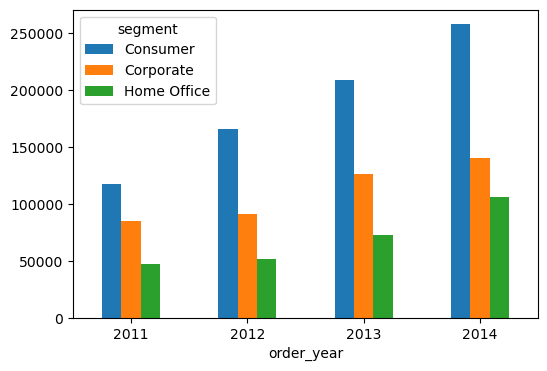

In [167]:
seg_df.plot(kind='bar', figsize=(6,4), rot=0)

**Consumer Segment** is most profitable and its profit is **increasing year-over-year**.

### **How the customers are distributed across the countries.**

In [168]:
# requirement gathering of data for analysis
data = order_df[['customer_name', 'country']]
customer_df = data.groupby(['country']).agg(
    customer_count = ('customer_name', 'count')
)
customer_df.reset_index().head()

,country,customer_count
0,Afghanistan,55
1,Albania,16
2,Algeria,196
3,Angola,122
4,Argentina,390


### **Product Analysis**
1. Which country has top sales?
2. Which are the top 5 profit-making product types on a yearly basis
3. How is the product price varying with sales - Is there any increase in sales with the decrease in price at a day level
4. What is the average delivery time across the counties - bar plot


#### **Which country has top sales?**

In [169]:
order_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'order_year',
       'order_month', 'order_week', 'order_dayofyear',
       'unique_customer_within_year'],
      dtype='object')

                sales_sum  sales_mean
country                              
United States  2297200.86      229.86
Australia       925235.85      326.13
France          858931.08      303.83
China           700562.02      372.64
Germany         628840.03      304.52 



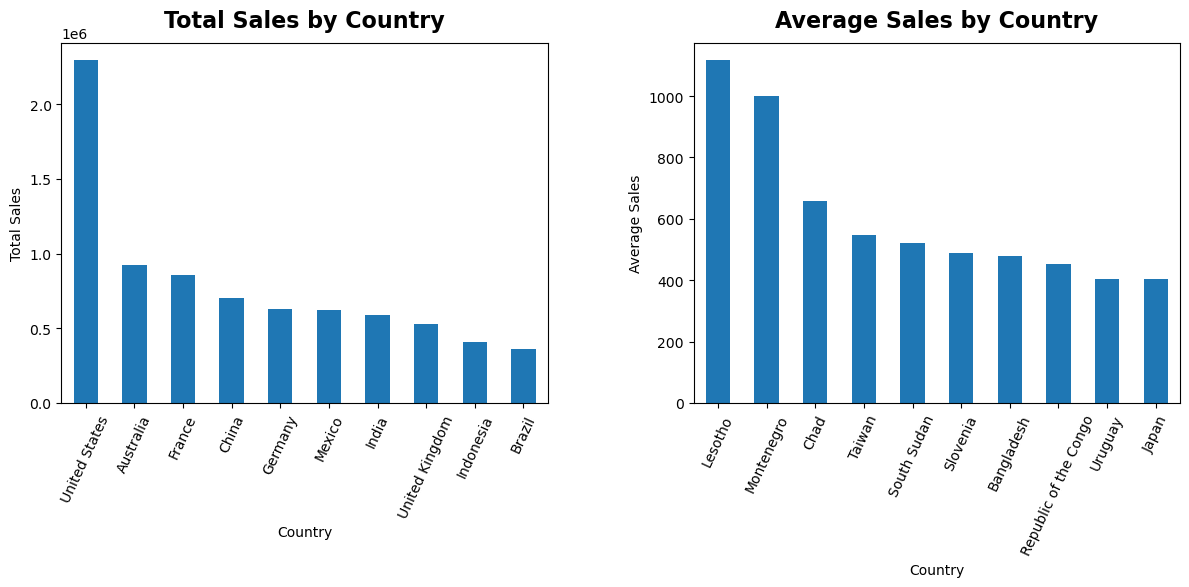

In [170]:
# requirement gathering data for analysis
data = order_df[['country', 'sales']]
country_df = data.groupby(['country']).agg(
    sales_sum = ('sales', 'sum'),
    sales_mean = ('sales', 'mean')).round(2)
new_country_df = country_df.sort_values(by=['sales_sum'], ascending=False)
print(new_country_df.head(),'\n')
# visualize the data
fig, ax = plt.subplots(1, 2, figsize=(12,6))
# sales sum by country for top 10
new_country_df.loc[:,'sales_sum'][:10].plot(kind='bar', rot=65, ax=ax[0])
ax[0].set_title("Total Sales by Country", fontsize=16, fontweight='bold', y=1.02)
ax[0].set_xlabel('Country')
ax[0].set_ylabel("Total Sales")

# average sales by country for top 10
country_avg_df = country_df.sort_values(by=['sales_mean'], ascending=False)
country_avg_df.loc[:, 'sales_mean'][:10].plot(kind = 'bar', rot=65, ax=ax[1])
ax[1].set_title('Average Sales by Country', fontsize=16, fontweight='bold', y=1.02)
ax[1].set_xlabel('Country')
ax[1].set_ylabel('Average Sales')

# Add label and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**United States** has top sales.

### **Which are the top 5 profit-making product types on a yearly basis.**

In [171]:
order_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'order_year',
       'order_month', 'order_week', 'order_dayofyear',
       'unique_customer_within_year'],
      dtype='object')

In [172]:
#requirement gathering data for analysis
product_df = order_df.groupby(['order_year', 'sub-category']).agg(
   profit = ('profit', 'sum')
)
product_df.head()

profit
order_year sub-category            
2011       Accessories   15719.8606
           Appliances    22838.4413
           Art           10399.0233
           Binders       11447.2053
           Bookcases     27518.8575

In [173]:
product_df.reset_index(inplace=True)
#empty dataframe
profit_df = pd.DataFrame(columns = product_df.columns)
year_df = product_df.groupby(['order_year'])
# compute top 5 profit product type each year
for i, v in year_df:
    top5_profit_category = v.nlargest(5, 'profit')
    profit_df = pd.concat([profit_df, top5_profit_category], ignore_index=True)


In [174]:
display(profit_df.style.background_gradient(cmap='YlOrRd', subset=pd.IndexSlice[:,'profit']))

,order_year,sub-category,profit
0,2011,Phones,53927.489500
1,2011,Copiers,30375.093440
2,2011,Chairs,29943.157100
3,2011,Bookcases,27518.857500
4,2011,Appliances,22838.441300
5,2012,Copiers,51843.227600
6,2012,Phones,45223.049800
7,2012,Accessories,33507.100200
8,2012,Chairs,28755.346700
9,2012,Bookcases,28137.267100


### **How is the product price varying with sales - Is there any increase in sales with the decrease in price at a day level?**

### **What is the average delivery time across the counties - bar plot**

In [175]:
print(f"Order dataframe shape = {order_df.shape[0]}")
print(f"Number of dates where ship data is greater than equal to order date = {np.sum(order_df['ship_date'] >= order_df['order_date'])}")
print({order_df.shape[0]} == {np.sum(order_df['ship_date'] >= order_df['order_date'])})

Order dataframe shape = 51290
Number of dates where ship data is greater than equal to order date = 51290
True


,delivery_time,delivery_time_in_hrs
country,,
South Sudan,5.5000,132.0000
Armenia,5.3333,128.0000
Macedonia,5.2500,126.0000
Jamaica,5.0323,120.7742
Tajikistan,5.0000,120.0000


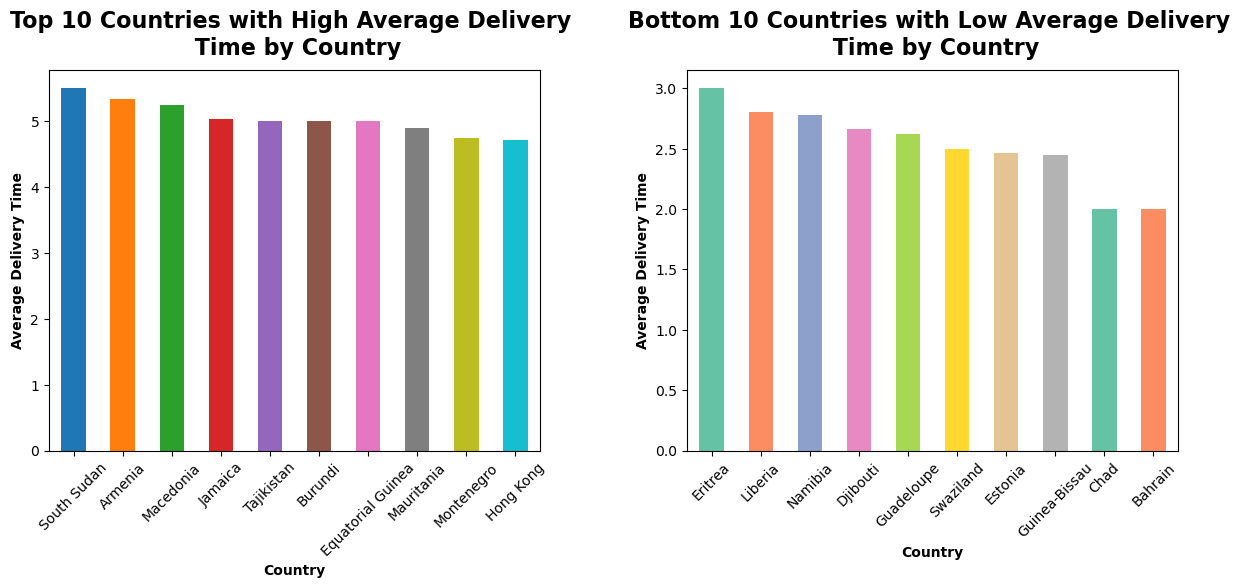

In [207]:
order_df['delivery_time']= (order_df['ship_date'] - order_df['order_date']).dt.days
# compute average delivery time across countries
delivery_df = order_df.groupby(['country']).agg({'delivery_time': 'mean'})#.sort_values(by='delivery_time', ascending=False)
delivery_df['delivery_time_in_hrs'] = delivery_df['delivery_time']*24
delivery_df.sort_values(by='delivery_time_in_hrs', ascending=False, inplace=True)
display(delivery_df.head().round(4))
# visualize the top and bottom 10 delivery time by country
fig, ax = plt.subplots(1, 2, figsize=(12,6))
# top 10 country 
delivery_df.loc[:,'delivery_time'][:10].plot(kind='bar', color = sns.color_palette(n_colors=10), ax=ax[0], rot=45)
ax[0].set_title("Top 10 Countries with High Average Delivery \n Time by Country", fontsize=16, fontweight='bold', y=1.02)
ax[0].set_xlabel('Country', fontweight='bold')
ax[0].set_ylabel("Average Delivery Time", fontweight='bold')
# Bottom 10 country
delivery_df.loc[:,'delivery_time'][-10:].plot(kind='bar', color = sns.color_palette(palette = 'Set2',n_colors=10), ax=ax[1], rot=45)
ax[1].set_title("Bottom 10 Countries with Low Average Delivery \n Time by Country", fontsize=16, fontweight='bold', y=1.02)
ax[1].set_xlabel('Country', fontweight='bold')
ax[1].set_ylabel("Average Delivery Time", fontweight='bold')

# Add labels and layouts
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

### **Count how many times a Product was Returned**

If a product was returned before, it is likely that it might be returned again. We will count how many times a product was returned, if it never got returned we will impute the missing values using 0. Remember, more products ordered likely means more returns so we will use the ratio of returns.


# sum 0 means the products were never returned
product_returns_count = orders_merged.groupby(['product id'])['returned_new'].sum()
product_returns_count = product_returns_count.sort_values()
product_returns_count[:5]

product_returns_ratio = orders_merged.groupby(['product id'])['returned_new'].mean()
product_returns_ratio.sort_values()
product_returns_ratio[:5]

# Lets insert columns product_returns_count and product_returns_ratio in the orders_merged dataframe
orders_merged['product_id_return_count'] = orders_merged['product id'].map(lambda x: product_returns_count[x])
orders_merged['product_id_return_ratio'] = orders_merged['product id'].map(lambda x: product_returns_ratio[x])

# visualize the data
fig, ax = plt.subplots(1, 2, figsize=(8,6))
orders_merged.groupby('returned_new')['product_id_return_count'].plot(kind='kde',legend=True,ax=ax[0])
orders_merged.groupby('returned_new')['product_id_return_ratio'].plot(kind='kde',legend=True,ax=ax[1])

# add titles and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

# lets look at the Product.ID and its return counts and ratio
print(orders_merged[['product id', 'product_id_return_count', 'product_id_return_ratio']].head())

# correlaton between return count and return ratio
print("\nCorrelation between Product ID Return Count and Product ID Return Ratio:")
orders_merged[['product_id_return_count', 'product_id_return_ratio']].corr()
